# A single-band model for La$_{2}$CuO$_{4}$: Metal-insulator transitions

In this tutorial, we extend our study of La$_{2}$CuO$_{4}$ by exploring how electron correlations drive a metal-insulator transition within the DMFT framework. Starting from the effective low-energy model built in the previous tutorial, we will increase the strength of the Hubbard interaction $U$, rerun the DMFT calculation, and analyze how the spectral function evolves from metallic to insulating behavior.

Specifically, you will learn how to analyze how the local spectral function change across the metal-insulator transition.

### 🧪 Exercise 0: Write a generic DMFT function
Let's turn our DMFT loop that we wrote in [Tutorial X]() into a free function that takes as argument a few parameters. We can then use this function to effectively explore parameter spaces. For example, we would like to study the metal-insulator transition of La$_{2}CuO$_{4}$ wihtin our single-band approximation for this material.

#### 🧩 Your Task
Write a function called ``solve_dmft_equations`` with the following api:

```python
def solve_dmft_equations(target_density, beta, obe, h_int, solver, solver_params, bz_int=modest.BzIntOptions(), n_dmft_loops=15, n_iw=251):
    """
    your implementation
    """
    return mu, solver_results
```

In [1]:
import triqs_modest as modest
from triqs.gf import BlockGf, MeshImFreq
import numpy as np

def solve_dmft_equations(target_density, beta, obe, h_int, solver, solver_params, 
                         bz_int=modest.BzIntOptions(), 
                         n_dmft_loops=15, 
                         n_iw=251):
    
    # Matsubara mesh
    mesh = MeshImFreq(beta, S='Fermion', n_iw=251)

    # find mu
    mu = modest.find_chemical_potential(target_density, obe, mesh, bz_int, verbosity=False) 

    # compute hloc
    hloc0_C =  modest.impurity_levels(obe) - mu
    hloc0   = np.asarray(hloc0_C[0],dtype=complex).reshape(2,1,1) # Block2Matrix -> BlockMatrix

    # compute Gloc
    Gloc_C  = modest.gloc(mesh, obe, mu, bz_int)
    Gloc = BlockGf(gf_struct=[('up',1), ('down',1)], mesh=mesh) # Block2Gf -> BlockGf
    Gloc['up']   << Gloc_C['0','up']
    Gloc['down'] << Gloc_C['0','down']

    # compute Δ
    Delta_iw = modest.hybridization(hloc0, Gloc)
    
    for n_iter in range(n_dmft_loops):

        # solve!
        solver_results = solver(Delta_iw, hloc0, h_int, **solver_params)

        # update Sigma!
        Sigma_static_C  = np.asarray(solver_results.Sigma_Hartree, dtype=complex).reshape(1,2,1,1) # BlockMatrix -> Block2Matrix

        Sigma_dynamic_C  = Gloc_C.copy() # BlockGf -> Block2Gf
        Sigma_dynamic_C['0','up']  << solver_results.Sigma_dynamic['up']
        Sigma_dynamic_C['0','down'] << solver_results.Sigma_dynamic['down']

        # update mu!
        mu     = modest.find_chemical_potential(target_density, obe, Sigma_dynamic_C, Sigma_static_C, bz_int, verbosity=False)

        # update Gloc!
        Gloc_C  = modest.gloc(obe, mu, Sigma_dynamic_C, Sigma_static_C, bz_int)
        Gloc['up']   << Gloc_C['0','up']
        Gloc['down'] << Gloc_C['0','down']

        # update hloc0! εd - μ
        hloc0_C = modest.impurity_levels(obe) - mu
        hloc0   = np.asarray(hloc0_C[0],dtype=complex).reshape(2,1,1) # Block2Matrix -> BlockMatrix

        # update Δ!
        Delta_iw = modest.hybridization(hloc0, Gloc, solver_results.Sigma_dynamic, solver_results.Sigma_Hartree)
        print(f"Δn = |n_lattice - n_impurity| = {abs(Gloc.total_density()-solver_results.G_iw.total_density())}")
        
    return mu, solver_results

### 🧪 Exercise 1: Set up the data for your DMFT solver

Let's now use our function to run a new DMFT calculation now with an increased Coulomb interaction $U$. Let's try $U = 5$ eV. Your function takes the following parameters:

1. target electron density
2. inverse temperature 
3. one-body elements
4. interaction Hamiltonian
5. a solver,
6. and solver parameters

Start by appropriately initializing all of this data.

In [2]:
from triqs.operators import n

# electron density
target_density    = 1.0

# inverse temperature
beta = 10.0

# obe
obe  = modest.one_body_elements_from_wannier90("./data/mlwf/lco", # wannier file path
                                               "NonPolarized",  # spin kind
                                               [modest.AtomicShellT(dft_idx=0, cls_idx=0, l=2, dim=1)] # orbital(s)
                                              )

# interaction
U = 5.0
h_int = U*n('up',0)*n('down',0)

# my solver is cthyb_solve
from utils.solvers import solve as cthyb_solve

# solver parameters
solver_params = dict(length_cycle=80, n_cycles = int(1e+6), n_warmup_cycles = int(1e+3), 
                     perform_tail_fit=True, fit_min_w=5, fit_max_w=9, imag_threshold = 1e-6)

Starting serial run at: 2025-08-06 10:19:23.755740


## 🔍 Finding the metal-insulator transition

### 🧪 Exercise 2: Test your DMFT function

Now that we have our data call the DMFT function you wrote in the first Exercise. Let's use ``n_dmft_loops=2`` to make sure everything is running properly.

In [3]:
mu, solver_results = solve_dmft_equations(target_density, beta, obe, h_int, cthyb_solve, solver_params, n_dmft_loops=2)


╔╦╗╦═╗╦╔═╗ ╔═╗  ┌─┐┌┬┐┬ ┬┬ ┬┌┐ 
 ║ ╠╦╝║║═╬╗╚═╗  │   │ ├─┤└┬┘├┴┐
 ╩ ╩╚═╩╚═╝╚╚═╝  └─┘ ┴ ┴ ┴ ┴ └─┘

The local Hamiltonian of the problem:
0.0898123*c_dag('down',0)*c('down',0) + 0.0898123*c_dag('up',0)*c('up',0) + 5*c_dag('down',0)*c_dag('up',0)*c('up',0)*c('down',0)
Using autopartition algorithm to partition the local Hilbert space
Found 4 subspaces.

Warming up ...
10:19:25 100% ETA 00:00:00 cycle 999 of 1000



Accumulating ...
10:19:25   0% ETA 00:01:12 cycle 1380 of 1000000
10:19:27   3% ETA 00:01:07 cycle 30546 of 1000000
10:19:29   6% ETA 00:01:05 cycle 66769 of 1000000
10:19:33  11% ETA 00:01:02 cycle 111800 of 1000000
10:19:37  16% ETA 00:00:58 cycle 166904 of 1000000
10:19:42  23% ETA 00:00:54 cycle 235481 of 1000000
10:19:48  32% ETA 00:00:48 cycle 322908 of 1000000
10:19:55  43% ETA 00:00:40 cycle 431835 of 1000000
10:20:05  56% ETA 00:00:30 cycle 567024 of 1000000
10:20:17  73% ETA 00:00:18 cycle 735375 of 1000000
10:20:32  94% ETA 00:00:03 cycle 947363 of 1000000
10:20:36 1

/var/folders/30/m529ltnn38dcg34ksgsm93t80000gn/T/ipykernel_8944/1494886254.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  hloc0   = np.asarray(hloc0_C[0],dtype=complex).reshape(2,1,1) # Block2Matrix -> BlockMatrix
/var/folders/30/m529ltnn38dcg34ksgsm93t80000gn/T/ipykernel_8944/1494886254.py:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  hloc0   = np.asarray(hloc0_C[0],dtype=complex).reshape(2,1,1) # Block2Matrix -> BlockMatrix



╔╦╗╦═╗╦╔═╗ ╔═╗  ┌─┐┌┬┐┬ ┬┬ ┬┌┐ 
 ║ ╠╦╝║║═╬╗╚═╗  │   │ ├─┤└┬┘├┴┐
 ╩ ╩╚═╩╚═╝╚╚═╝  └─┘ ┴ ┴ ┴ ┴ └─┘

The local Hamiltonian of the problem:
-0.562226*c_dag('down',0)*c('down',0) + -0.562226*c_dag('up',0)*c('up',0) + 5*c_dag('down',0)*c_dag('up',0)*c('up',0)*c('down',0)
Using autopartition algorithm to partition the local Hilbert space
Found 4 subspaces.

Warming up ...
10:20:37 100% ETA 00:00:00 cycle 999 of 1000



Accumulating ...
10:20:37   0% ETA 00:01:04 cycle 1537 of 1000000
10:20:39   3% ETA 00:01:01 cycle 33598 of 1000000
10:20:42   7% ETA 00:00:58 cycle 73782 of 1000000
10:20:45  12% ETA 00:00:55 cycle 124400 of 1000000
10:20:49  18% ETA 00:00:50 cycle 188780 of 1000000
10:20:54  26% ETA 00:00:45 cycle 267343 of 1000000
10:21:00  36% ETA 00:00:39 cycle 365697 of 1000000
10:21:08  48% ETA 00:00:32 cycle 488828 of 1000000
10:21:17  64% ETA 00:00:22 cycle 642849 of 1000000
10:21:30  83% ETA 00:00:10 cycle 832139 of 1000000
10:21:40 100% ETA 00:00:00 cycle 999999 of 1000000


[Rank 0]

elta_down_down: 0.0252935
Move  Shift one operator: 0.533688
[Rank 0] Warmup lasted: 0.063913 seconds [00:00:00]
[Rank 0] Simulation lasted: 62.969 seconds [00:01:02]
[Rank 0] Number of measures: 1000000
Total number of measures: 1000000
Average sign: 1
Average order: 4.63488
Auto-correlation time: 1.41087


### 🧪 Exercise 3: Check your Green's function and self-energy

Let's plot our current Green's function and self-energy after a couple of DMFT iterations.

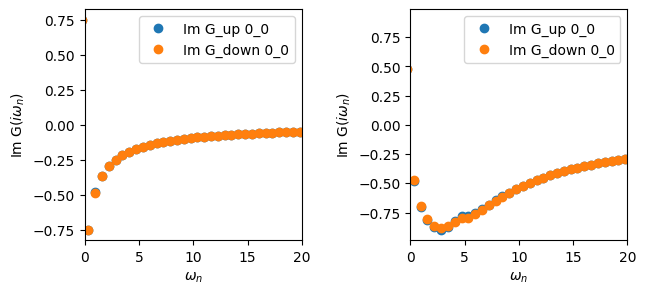

In [4]:
from triqs.plot.mpl_interface import oplot, plt
fig, ax = plt.subplots(1,2,sharex=True, figsize=(7,3))
ax[0].oplot(solver_results.G_iw.imag, 'o')
ax[1].oplot(solver_results.Sigma_iw.imag, 'o')
ax[0].set_xlim(0,20)
plt.subplots_adjust(wspace=0.5)
plt.show()

### 🧪 Exercise 4: Load converged reference data

In the interest of time, let's load pre-converged DMFT data for this $U$ value. You can load the reference data from the file ``lco-beta=10.0-U=5.0.h5`` in the ``ref_data`` directory.

In [26]:
from h5 import HDFArchive
from triqs.gf import MeshImFreq, BlockGf

with HDFArchive('ref_data/lco-beta=10.0-U=5.0.h5') as ar:
    last_iter = str(len(ar)-1)
    mu = ar[last_iter]['mu']
    Sigma_iw = ar[last_iter]['Sigma_iw']
    G_iw = ar[last_iter]['G_iw']

### 🧪 Exercise 5: Plot converged results

Now let's plot the imaginary part of the converged Green's function and self-energy.

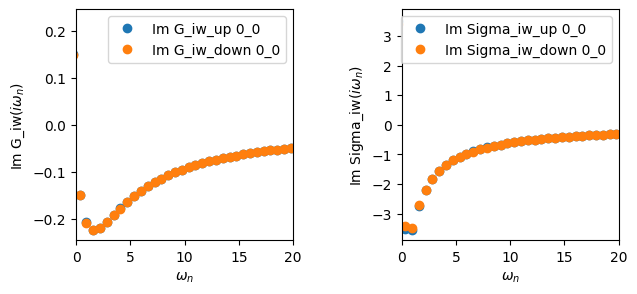

In [27]:
from triqs.plot.mpl_interface import oplot, plt
fig, ax = plt.subplots(1,2,sharex=True, figsize=(7,3))
ax[0].oplot(G_iw.imag, 'o')
ax[1].oplot(Sigma_iw.imag, 'o')
ax[0].set_xlim(0,20)
plt.subplots_adjust(wspace=0.5)
plt.show()

### 🧪 Exercise 6: Compare and contrast

Compare and contrast the converged results to your previous result obtained at lower values of $U$. What are the qualitative differences between the Green's function and self-energy at these two values of $U$.

For $U = 3.6$ eV, we saw that the Green's function was finite as $\omega_{n}\rightarrow 0$, while for the $U = 5$ eV results we see that the Green's function as an upturn at low $U$ indicating the suppression of spectral weight at the Fermi level and therefore the opening of a Mott gap. Similarly, the imaginary part of the self-energy is diverging as $\omega_{n}\rightarrow 0$ goes to zero for the larger value of $U$, while for smaller value of $U$ the self-energy show metallic behavior.

### 🧪 Exercise 7: Real-frequency spectral function

Let's analytically continue our converged Green's function and plot the resulting spectral function.

In [59]:
from utils.maxent import Aw_from_maxent

mesh, Aw = Aw_from_maxent(G_iw, omega_min=-10, omega_max=10,
                          alpha_min=1e-2, alpha_max=1e2, 
                          n_alpha_points=50, n_omega_points=250, 
                          error=0.06)

Calculating diagonal elements.
Calling MaxEnt for element 0 0
2025-08-06 10:51:13.912522
MaxEnt run
TRIQS application maxent
Copyright(C) 2018 Gernot J. Kraberger
Copyright(C) 2018 Simons Foundation
Authors: Gernot J. Kraberger and Manuel Zingl
This program comes with ABSOLUTELY NO WARRANTY.
This is free software, and you are welcome to redistributeit under certain conditions; see file LICENSE.
Please cite this code and the appropriate original papers (see documentation).

Minimal chi2: 8.043627264837823e-05
scaling alpha by a factor 1507 (number of data points)
alpha[ 0] =   1.50700000e+05, chi2 =   4.86493102e+02, n_iter=       4 
alpha[ 1] =   1.24876466e+05, chi2 =   4.83426171e+02, n_iter=       3 
alpha[ 2] =   1.03477981e+05, chi2 =   4.79774921e+02, n_iter=       3 
alpha[ 3] =   8.57462811e+04, chi2 =   4.75440067e+02, n_iter=       3 
alpha[ 4] =   7.10530361e+04, chi2 =   4.70310727e+02, n_iter=       3 
alpha[ 5] =   5.88775849e+04, chi2 =   4.64265463e+02, n_iter=       3 

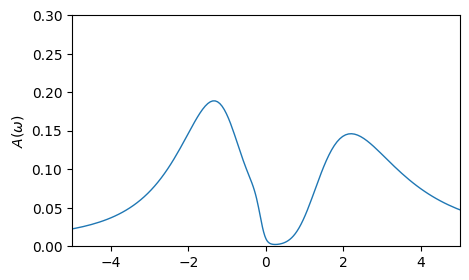

In [63]:
fig, ax = plt.subplots(figsize=(5,3))
ax.plot(mesh, Aw['up'].get_A_out('LineFitAnalyzer')[0,0].real, lw=1)
ax.set_ylabel(r'$A(\omega)$'); ax.set_xlim(-5,5); ax.set_ylim(0, 0.3)
plt.show()

### 🧪 Exercise 8: Real-frequency self-energy

Let's analytically continue our converged self-energy and plot it.

In [64]:
from utils.maxent import Sigma_w_from_maxent

Sigma_w = Sigma_w_from_maxent(Sigma_iw, error=0.04)

Calculating diagonal elements.
Calling MaxEnt for element 0 0
2025-08-06 10:53:15.051884
MaxEnt run
TRIQS application maxent
Copyright(C) 2018 Gernot J. Kraberger
Copyright(C) 2018 Simons Foundation
Authors: Gernot J. Kraberger and Manuel Zingl
This program comes with ABSOLUTELY NO WARRANTY.
This is free software, and you are welcome to redistributeit under certain conditions; see file LICENSE.
Please cite this code and the appropriate original papers (see documentation).

Minimal chi2: 0.00023157126447562285
scaling alpha by a factor 1507 (number of data points)
alpha[ 0] =   1.50700000e+05, chi2 =   1.50769761e+03, n_iter=       4 
alpha[ 1] =   1.03477981e+05, chi2 =   1.47498918e+03, n_iter=       3 
alpha[ 2] =   7.10530361e+04, chi2 =   1.43039389e+03, n_iter=       3 
alpha[ 3] =   4.87884852e+04, chi2 =   1.37119577e+03, n_iter=       3 
alpha[ 4] =   3.35005570e+04, chi2 =   1.29530773e+03, n_iter=       3 
alpha[ 5] =   2.30031188e+04, chi2 =   1.20207796e+03, n_iter=       3

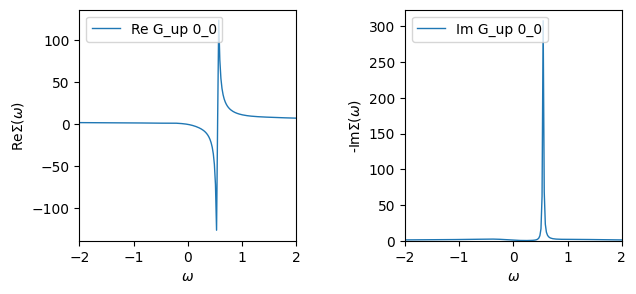

In [67]:
fig, ax = plt.subplots(1,2,sharex=True, figsize=(7,3))
# maxent
ax[0].oplot(Sigma_w['up']-Sigma_w['up'][0,0](0.0).real, mode='R', lw=1)
ax[1].oplot(-Sigma_w['up'], mode='I', lw=1)
ax[0].legend(loc='upper left'); ax[1].legend(loc='upper left')
ax[0].set_xlim(-2,2); ax[1].set_ylim(0, ); 
ax[0].set_ylabel(r'Re$\Sigma(\omega)$'); ax[1].set_ylabel(r'-Im$\Sigma(\omega)$')
plt.subplots_adjust(wspace=0.5)
plt.show()

### 🧪 Exercise 9: Real-frequency spectrum along high-symmetry lines

Finally, let's use our real-frequency self-energy to obtain our spectral function along high-symmetry lines in the Brillouin zone.

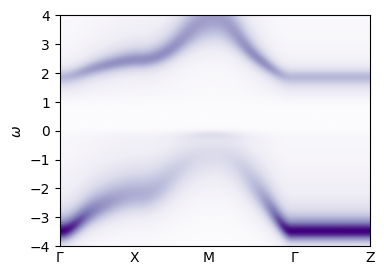

In [69]:
import triqs_modest as modest
from triqs.lattice.utils import k_space_path
from utils.mpl_interface import *

# create high-symmetry path
G = [0.00,  0.00,  0.00]
X = [0.25, -0.25,  0.25]
M = [0.00,  0.00,  0.50]
Z = [0.25,  0.25, -0.25]

segments = [(G,X), (X,M), (M, G), (G,Z)]
k_points, k_lin, k_ticks = k_space_path(segments)


# load in obe or the TB hamiltonian
obe  = modest.one_body_elements_from_wannier90("./data/mlwf/lco", 
                                               "NonPolarized", 
                                               [modest.AtomicShellT(dft_idx=0, cls_idx=0, l=2, dim=1)])

# compute the disperion along the high-symmetry directions
e_k = obe.H[0](k_points).real

# compute the spectral function
A_kw = momentum_resolved_spectral_function(e_k, mu, Sigma_w['up'], broadening=0.1)

fig, ax = plt.subplots(figsize=(4,3))

# plot the spectral function
ax.plot_spectral_function(A_kw, k_lin, k_ticks, [r'$\Gamma$', 'X', 'M', r'$\Gamma$', 'Z'], cmap='Purples', vmin=0)

ax.set_ylim(-4,4)
plt.show()